DATASET
Shape: (20640, 10)

Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'median_house_value']

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

Features used by the model:
 - longitude
 - latitude
 - housing_median_age
 - total_rooms
 - total_bedrooms
 - population
 - households
 - median_income
 - location_<1H OCEAN
 - location_INLAND
 - location_ISLAND
 - location_NEAR BAY
 - location_NEAR OCEAN

Total numerical model features: 13

Training samples: 16512
Testing samples : 4128

TRAINING LINEAR REGRESSION FROM SCRATCH
Epoch     0 | MSE: 13,279,376,385.46
Epoch   500 | MSE: 4,768,913,102.86
Epoch  1000 | MSE: 4,683,927,582.43
Epoch  1500 | 

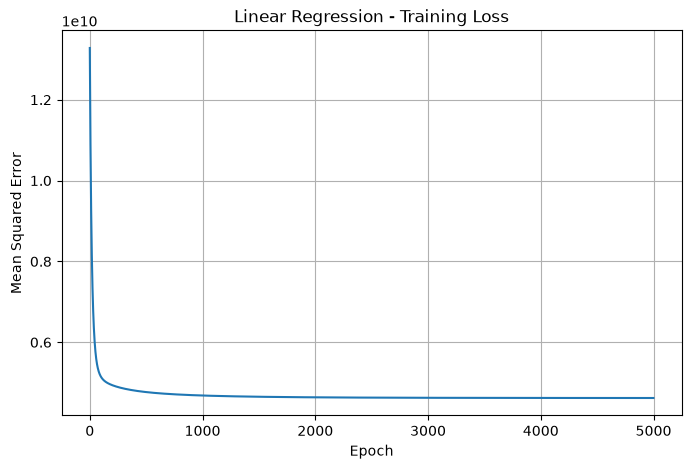

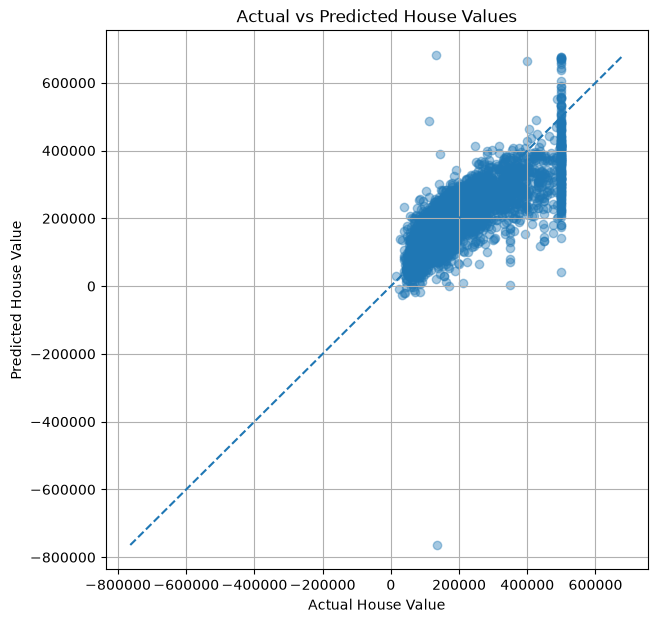


EXPERIMENT COMPLETE
Algorithm       : Linear Regression
Training Method : Gradient Descent
Implementation  : From Scratch using NumPy
Input Features  : 13
MAE             : $51,043.32
RMSE            : $71,685.48
R²              : 0.6182


In [8]:
# ============================================================
# HOUSE PRICE PREDICTION
# LINEAR REGRESSION FROM SCRATCH USING NUMPY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("housing.csv")

print("=" * 65)
print("DATASET")
print("=" * 65)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())


# ============================================================
# 2. USE ALL AVAILABLE INPUT FEATURES
# ============================================================

# Every feature in the dataset is used.
# Only median_house_value is excluded because it is the target.

features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "ocean_proximity"
]

target = "median_house_value"

data = df[features + [target]].copy()


# ============================================================
# 3. HANDLE MISSING VALUES
# ============================================================

# total_bedrooms contains missing values.
# Replace missing values with the median of that column.

data["total_bedrooms"] = data["total_bedrooms"].fillna(
    data["total_bedrooms"].median()
)


# ============================================================
# 4. ENCODE CATEGORICAL FEATURE
# ============================================================

# ocean_proximity is categorical.
#
# Example:
# <1H OCEAN
# INLAND
# ISLAND
# NEAR BAY
# NEAR OCEAN
#
# Convert these categories into numerical columns.

location_dummies = pd.get_dummies(
    data["ocean_proximity"],
    prefix="location",
    dtype=float
)


# Remove categorical column and target,
# then add encoded location columns.

X_df = pd.concat(
    [
        data.drop(
            columns=["ocean_proximity", target]
        ),
        location_dummies
    ],
    axis=1
)

y = data[target].values.astype(float)

feature_names = X_df.columns.tolist()

X = X_df.values.astype(float)


print("\nFeatures used by the model:")
for feature in feature_names:
    print(" -", feature)

print("\nTotal numerical model features:", X.shape[1])


# ============================================================
# 5. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

np.random.seed(42)

# Shuffle indices

indices = np.random.permutation(len(X))

# 80% training / 20% testing

split_index = int(0.80 * len(X))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 6. STANDARDIZATION FROM SCRATCH
# ============================================================

# Standardization:
#
# x_scaled = (x - mean) / standard_deviation
#
# Statistics are calculated ONLY from the training set.

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Prevent division by zero

std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std


# ============================================================
# 7. LINEAR REGRESSION FROM SCRATCH
# ============================================================

class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=5000):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.loss_history = []


    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize weights

        self.weights = np.zeros(n_features)

        # Initialize bias using target mean

        self.bias = np.mean(y)

        # Gradient Descent

        for epoch in range(self.epochs):

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            y_pred = (
                X @ self.weights
                + self.bias
            )

            # ------------------------------------------------
            # Calculate error
            # ------------------------------------------------

            error = y_pred - y

            # ------------------------------------------------
            # Mean Squared Error
            # ------------------------------------------------

            mse = np.mean(error ** 2)

            self.loss_history.append(mse)

            # ------------------------------------------------
            # Calculate gradients
            # ------------------------------------------------

            dw = (
                (2 / n_samples)
                * (X.T @ error)
            )

            db = (
                (2 / n_samples)
                * np.sum(error)
            )

            # ------------------------------------------------
            # Gradient descent update
            # ------------------------------------------------

            self.weights -= (
                self.learning_rate * dw
            )

            self.bias -= (
                self.learning_rate * db
            )

            # Display training progress

            if epoch % 500 == 0:

                print(
                    f"Epoch {epoch:5d} | "
                    f"MSE: {mse:,.2f}"
                )


    def predict(self, X):

        return (
            X @ self.weights
            + self.bias
        )


# ============================================================
# 8. TRAIN MODEL
# ============================================================

print("\n" + "=" * 65)
print("TRAINING LINEAR REGRESSION FROM SCRATCH")
print("=" * 65)

model = LinearRegressionScratch(
    learning_rate=0.01,
    epochs=5000
)

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 9. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 10. EVALUATION METRICS
# ============================================================

# -------------------------
# MAE
# -------------------------

MAE = np.mean(
    np.abs(y_test - y_pred)
)


# -------------------------
# MSE
# -------------------------

MSE = np.mean(
    (y_test - y_pred) ** 2
)


# -------------------------
# RMSE
# -------------------------

RMSE = np.sqrt(MSE)


# -------------------------
# R²
# -------------------------

SS_res = np.sum(
    (y_test - y_pred) ** 2
)

SS_tot = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

R2 = 1 - (
    SS_res / SS_tot
)


# ============================================================
# 11. MODEL PERFORMANCE
# ============================================================

print("\n" + "=" * 65)
print("MODEL PERFORMANCE")
print("=" * 65)

print(f"MAE  : ${MAE:,.2f}")
print(f"RMSE : ${RMSE:,.2f}")
print(f"R²   : {R2:.4f}")


# ============================================================
# 12. LEARNED PARAMETERS
# ============================================================

print("\n" + "=" * 65)
print("LEARNED PARAMETERS")
print("=" * 65)

for feature, weight in zip(
    feature_names,
    model.weights
):

    print(
        f"{feature:30s}: "
        f"{weight:,.4f}"
    )

print(
    f"{'Bias':30s}: "
    f"{model.bias:,.4f}"
)


# ============================================================
# 13. SAVE PREDICTIONS
# ============================================================

results = pd.DataFrame({

    "Actual Price": y_test,

    "Predicted Price": y_pred,

    "Absolute Error":
        np.abs(y_test - y_pred)

})

results.to_csv(
    "linear_regression_output.csv",
    index=False
)

print(
    "\nSaved: linear_regression_output.csv"
)


# ============================================================
# 14. SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 65)
print("SAMPLE PREDICTIONS")
print("=" * 65)

print(
    results.head(10).to_string(
        index=False
    )
)


# ============================================================
# 15. TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    model.loss_history
)

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.title(
    "Linear Regression - Training Loss"
)

plt.grid(True)

plt.show()


# ============================================================
# 16. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# Perfect prediction line

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual House Value"
)

plt.ylabel(
    "Predicted House Value"
)

plt.title(
    "Actual vs Predicted House Values"
)

plt.grid(True)

plt.show()


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("EXPERIMENT COMPLETE")
print("=" * 65)

print("Algorithm       : Linear Regression")
print("Training Method : Gradient Descent")
print("Implementation  : From Scratch using NumPy")
print("Input Features  :", len(feature_names))
print(f"MAE             : ${MAE:,.2f}")
print(f"RMSE            : ${RMSE:,.2f}")
print(f"R²              : {R2:.4f}")